Question 1

What is a Decision Tree? Explain its structure (Root, Nodes, Leaves) with a real-life example.

Answer:

A Decision Tree is a supervised machine learning algorithm used for both classification and regression tasks. It makes decisions by splitting data into smaller groups based on different conditions.

Structure of a Decision Tree:

Root Node: The first node that represents the entire dataset and starts the decision process.
Internal Nodes: Nodes where the data is split based on feature values.
Leaf Nodes: The final nodes that give the prediction or decision.

Real-life Example:

A bank wants to decide whether a customer will subscribe to a fixed deposit.

Root Node: Does the customer have a housing loan?
Internal Node: Is the customer's balance greater than 1000?
Leaf Node: Predict Yes or No for deposit subscription.

Question 2

Differentiate between Gini Impurity and Entropy. Which one is used by default in Scikit-learn and why?

Gini Impurity:
Measures the impurity of a dataset.
Faster to calculate because it does not use logarithms.
Commonly used in Decision Tree algorithms.

Entropy:
Measures the randomness or uncertainty of a dataset.
Slightly slower because it uses logarithmic calculations.
Also used for splitting but requires more computation.


Default in Scikit-learn:

Scikit-learn uses Gini Impurity as the default criterion (criterion='gini') because it is computationally faster and generally provides performance similar to Entropy.

Question 3

What is Overfitting in Decision Trees? How can we detect it using training and testing accuracy?

Answer:

Overfitting occurs when a Decision Tree learns the training data too closely, including noise and small details. As a result, it performs very well on the training data but poorly on new or unseen data.

How to detect Overfitting:

If the training accuracy is very high but the testing accuracy is much lower, the model is likely overfitting.
If both training and testing accuracies are similar and high, the model is performing well.
Reducing the tree depth or pruning the tree can help prevent overfitting.

Question 4

Explain Pruning in Decision Trees. What is the difference between Pre-pruning and Post-pruning?

Answer:

Pruning is the process of reducing the size of a Decision Tree by removing unnecessary branches. It helps improve the model's performance and reduces overfitting.

Difference between Pre-pruning and Post-pruning:

| Pre-pruning                                               | Post-pruning                                                              |
| --------------------------------------------------------- | ------------------------------------------------------------------------- |
| Stops the tree from growing too deep during training.     | Builds the full tree first, then removes unnecessary branches.            |
| Faster because the tree growth is limited early.          | Takes more time because pruning is done after the complete tree is built. |
| Uses parameters like `max_depth` and `min_samples_split`. | Removes branches based on performance after training.                     |

Conclusion:

Both methods help reduce overfitting and improve the model's ability to generalize to new data.

Q5. What is Feature Importance? How can it help businesses in decision-making?
Answer:

Feature Importance is a technique used in machine learning to measure how much each input feature contributes to the model's predictions. Features with higher importance have a greater influence on the model's decisions.

How it helps businesses in decision-making:

It identifies the most important factors affecting the outcome.
It helps businesses focus on the key variables that influence customer behavior.
It supports better decision-making by highlighting the features that have the greatest impact.
It improves model interpretability and helps in developing effective business strategies.

Example:
In a bank marketing model, if duration, balance, and age have the highest feature importance, the bank can focus its marketing campaigns on customers with these characteristics to improve the chances of getting a "yes" for a deposit.

In [238]:
# Q6: Import the library and load the dataset

import pandas as pd

# Load the dataset
df = pd.read_csv("bank.csv")

# Display the first 5 rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [239]:
# Q6: Display the shape of the dataset

print("Shape of Dataset:", df.shape)

Shape of Dataset: (11162, 17)


In [240]:
# Q6: Display the data types of all columns

print(df.dtypes)

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object


In [241]:
# Q6: Display the column names

print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')


Interpretation:

The dataset contains both numerical and categorical variables. Numerical variables include features such as age, balance, day, duration, campaign, pdays, and previous. Categorical variables include job, marital, education, default, housing, loan, contact, month, poutcome, and deposit. These variables will be used for building the Decision Tree model after preprocessing.

In [242]:
# Q7: Check for missing values

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


In [243]:
# Q7: Handle missing values (if any)

# Remove rows with missing values
df = df.dropna()

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


In [244]:
# Q7: Check for duplicate records

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [245]:
# Q7: Remove duplicate records

df = df.drop_duplicates()

print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows after cleaning: 0


Interpretation:

The dataset was checked for missing values and duplicate records. Missing values were handled (if present), and duplicate rows were removed. After data cleaning, the dataset is ready for preprocessing and model building.

In [246]:
# Q8: Convert categorical variables into numerical using Label Encoding

from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# Encode all categorical (object) columns
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Display the first 5 rows after encoding
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


Interpretation:

The categorical variables were converted into numerical values using the Label Encoding method. This preprocessing step is necessary because the Decision Tree algorithm requires numerical input for training. After encoding, the dataset is ready for feature selection and model building.

In [247]:
# Q9: Separate features (X) and target variable (y)

X = df.drop("deposit", axis=1)
y = df["deposit"]

print("Features (X) Shape:", X.shape)
print("Target (y) Shape:", y.shape)

Features (X) Shape: (11162, 16)
Target (y) Shape: (11162,)


In [248]:
# Q9: Split the dataset into training and testing sets (80:20)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (8929, 16)
Testing Features: (2233, 16)
Training Target: (8929,)
Testing Target: (2233,)


Interpretation:

The dataset was divided into features (X) and the target variable (y), where deposit is the target column. The data was then split into 80% training data and 20% testing data. The training data is used to train the Decision Tree model, while the testing data is used to evaluate its performance on unseen data. This helps in assessing how well the model generalizes and reduces the risk of overfitting.

In [249]:
# Q10: Build and train the Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


Interpretation:

The Decision Tree Classifier was trained using the Gini impurity criterion with a maximum depth of 5. Limiting the tree depth helps prevent overfitting by avoiding unnecessary splits, making the model simpler and improving its ability to generalize to new data.

In [250]:
# Q11: Evaluate the Decision Tree model

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Display Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Display Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8051948051948052

Confusion Matrix:
[[867 299]
 [136 931]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.74      0.80      1166
           1       0.76      0.87      0.81      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.80      2233



Interpretation:

The model was evaluated using Accuracy, Confusion Matrix, and Classification Report. The Confusion Matrix shows the number of correctly and incorrectly classified instances for each class. It helps identify true positives, true negatives, false positives, and false negatives, providing a clear understanding of the model's classification performance. The Classification Report further summarizes the model using Precision, Recall, and F1-score.

In [251]:
# Q12: Calculate training accuracy and testing accuracy

from sklearn.metrics import accuracy_score

# Predict on training data
train_pred = model.predict(X_train)

# Predict on testing data
test_pred = model.predict(X_test)

# Calculate training accuracy
train_accuracy = accuracy_score(y_train, train_pred)

# Calculate testing accuracy
test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy: 0.8149848807257252
Testing Accuracy : 0.8051948051948052


Interpretation:

The training and testing accuracies were compared to evaluate the model's performance.

If the training accuracy is much higher than the testing accuracy, the model is overfitting.
If both accuracies are low, the model is underfitting.
If the training and testing accuracies are close and reasonably high, the model is well-fitted and generalizes well to unseen data.

In [252]:
# Q13: Perform a pruning experiment

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create a pruned Decision Tree model
pruned_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_split=20,
    random_state=42
)

# Train the pruned model
pruned_model.fit(X_train, y_train)

# Make predictions
y_pred_pruned = pruned_model.predict(X_test)

# Calculate accuracy
pruned_accuracy = accuracy_score(y_test, y_pred_pruned)

print("Previous Model Accuracy:", accuracy)
print("Pruned Model Accuracy :", pruned_accuracy)

Previous Model Accuracy: 0.8051948051948052
Pruned Model Accuracy : 0.7653381101656964


Interpretation:

A pruned Decision Tree was built by setting max_depth=3 and min_samples_split=20. The accuracy of the pruned model was compared with the previous model. Pruning helps reduce overfitting by limiting the complexity of the tree. If the pruned model achieves similar or slightly lower accuracy while generalizing better, it is considered a better and more reliable model.

In [253]:
# Q14: Display the Feature Importance of all variables

import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

# Sort feature importance in descending order
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display feature importance
print(feature_importance)

      Feature  Importance
11   duration    0.595239
8     contact    0.121729
13      pdays    0.084299
6     housing    0.067469
10      month    0.054023
15   poutcome    0.044967
14   previous    0.013804
0         age    0.010691
5     balance    0.003250
12   campaign    0.002447
9         day    0.002081
7        loan    0.000000
1         job    0.000000
4     default    0.000000
2     marital    0.000000
3   education    0.000000


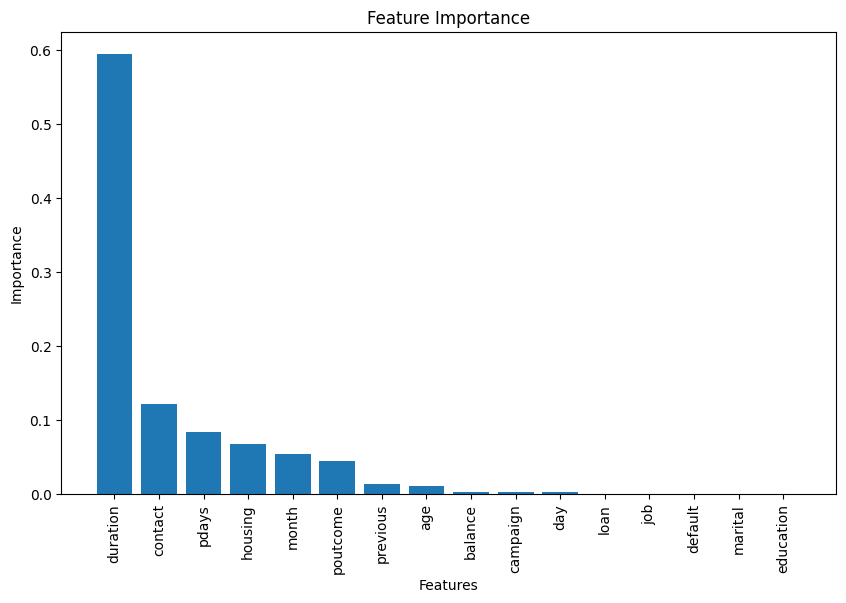

In [254]:
# Q14: Visualize Feature Importance

plt.figure(figsize=(10,6))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])

plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.show()

Interpretation:

The feature importance values indicate how much each variable contributes to the Decision Tree model's predictions. Features with higher importance scores have a greater influence on predicting whether a customer will subscribe to a deposit. These important features can help the bank identify the key factors affecting customer decisions and improve its marketing strategies.

Q15. Business Insights
Answer:

1. Which type of customers are more likely to say "yes"?

Based on the Decision Tree model, customers with favorable characteristics identified by the model (such as higher account balance, successful previous campaign outcomes, longer call duration, and other important features) are more likely to subscribe to a bank deposit.

2. What strategy should a bank use?

The bank should:

Target customers who are more likely to subscribe based on the model's predictions.
Provide personalized offers and financial products according to customer profiles.
Focus marketing efforts on high-potential customers to improve conversion rates and reduce marketing costs.